# Functions

In [2]:
# packages to import, read in the latest dataframe pickle
import pandas as pd
import numpy as np
import random
from matplotlib import pyplot as plt
import seaborn as sns
from hmmlearn import hmm
import ast
import pickle
import os
import scipy
import matplotlib
import colorsys
from colour import Color
from itertools import chain
import scipy.stats as stats
#import sigfig

matplotlib.rcParams['pdf.fonttype'] = 42

font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size'   : 14}

matplotlib.rc('font', **font)
#np.warnings.filterwarnings('ignore', category=np.VisibleDeprecationWarning)
pd.options.mode.chained_assignment = None 

In [3]:
#imports the preprocessed dataframes containing footprint sizes at each position around a TSS
def import_data(conditions, coding, s, e):
    genes_df=pd.DataFrame()
    for condition in conditions:
        for f in os.listdir('/mnt/d/Processed'):
            if condition in f and coding in f:
                print(f)
                tmp=pd.read_csv('/mnt/d/Processed/'+f, sep='\t', usecols=np.append(['gid','rid','condition','dataset'],np.arange(s,e).astype(str)))#, nrows=3)
                genes_df=pd.concat([tmp, genes_df], axis=0)
    return genes_df

#generates a dataframe used to make a heatmap showing the enrichment of different footprints w.r.t. TSS
def plot_meta_heatmap(reads_df,s,e, min_s,max_s,bin_size):
    m_d=pd.DataFrame()
    reads_df=reads_df.drop(['rid','gid','condition','dataset'], axis=1).fillna(0)[np.arange(s,e).astype(str)]
    reads_df[reads_df<=2]=0
    d=[]
    #iterate through size bins
    for s in range(min_s//bin_size,max_s//bin_size):
        df=reads_df.copy()
        #filter on size
        df=df.where(df >= (s)*bin_size,0)
        df=df.where(df < (s+1)*bin_size,0)
        #sum all footprints of size at position
        a=pd.DataFrame(df.sum(axis=0)).T
        d.append((s*bin_size))
        m_d=pd.concat([m_d,a], axis=0)
    m_d.index=d
    return m_d

#generates an array used to plot the enrichment of footprints of a specific size range within a specific range
def meta_line_plot(reads_df, start, end, fp_size_min, fp_size_max, plot_array):
    
    #generate a dataframe which converts the footprint size and gap size to one-hot
    count_df=reads_df.drop(['dataset','condition', 'gid','rid'], axis=1)
    count_df[count_df!=2]=1
    count_df[count_df==2]=0
    counts=count_df.sum(axis=0)
    count_df=[]
    counts=counts.loc[np.arange(start,end).astype(str)]
    
    #get rid of empty read bases in dataframe (2 is the placeholder)
    df=reads_df.drop(['dataset','condition', 'gid','rid'], axis=1)
    df[df <=2 ] = 0
    df=df.T
    df=df.loc[np.arange(start,end).astype(str)]
    df=df.T

    #mask all footprints outside of size range
    if fp_size_min:
        df=df.where(df > fp_size_min, 0)
    if fp_size_max:
        df=df.where(df < fp_size_max, 0)
    df=df.where(df == 0, 1)    
    
    #sum remaining reads, normalzie by counts
    df_a=df.sum(axis=0)
    df_a=np.array(df_a)/counts.to_numpy()
    df=''
    
    return df_a

In [4]:
def make_cp(colors, sizes):
    
    #start at empty RGBA
    cp =[tuple([0,0,0,0])]*sizes[0]
    
    #iterate through size range checkpoints
    for i in range(len(colors)-1):
        #grab colors provided
        cs=Color(colors[i])
        ce=Color(colors[i+1])
        #interpolate RGBA values from one color to next for each size between size range provided
        for j in list(cs.range_to(ce, sizes[i+1]-sizes[i])):
            j=list(j.rgb)
            j.append(1)
            j=tuple(j)
            cp.append(j)

    return matplotlib.colors.ListedColormap(cp)

#basic colorprofile for small footprints
colors=['#ed306f','#e42cf6','#f3aafa','#265de6','#33a040'] 
sizes=[20,            45,        55,   70,         100]
pol_cp=make_cp(colors, sizes)

#grey colorprofile for blocking unknown footprints
colors=['#949494','#949494'] 
sizes=[1,  1000]
mask_cp=make_cp(colors, sizes)

#green colorprofile for nucleosomes
colors==['#33a040','#33a040']
sizes=[20,  1000]
nuc_cp=make_cp(colors, sizes)

In [13]:
#given PRO-seq/CAGE-seq signal, call peaks
def call_peaks(signal_df, gtf_df, dataset, min_pos, max_pos, window_size, min_threshold,min_cov,plot):
    signal=signal_df.loc[signal_df['dataset']==dataset].loc[signal_df['pos'].isin(np.arange(min_pos, max_pos))]

    peak_dic={}
    k=0
    #iterate through genes
    for gene in gtf_df.loc[gtf_df['biotype']=='protein_coding']['gid']:
        maxes=[]
        #identify the maximum peak in the entire region, then assign minimum based on the threshold indicated
        min_peak = np.amax(signal[gene].to_numpy())/min_threshold
        #iterate through windows
        for i in range(max_pos-min_pos):
            window=signal[gene].to_numpy()[i:i+window_size]
            #check the max is above min coverage and min peak
            if np.amax(window)>min_cov and np.amax(window)>min_peak:
                maxes.append(np.argmax(window)+i+min_pos)
        #grab all unique peaks, store in dictionary
        maxes=np.unique(np.array(maxes))
        if len(maxes)>0:
            peak_dic[gene]=maxes
    return peak_dic

#shrink the size of footprints in an array so that you can look at only the middle x% for overlap analyses
def trim_back(arr, factor):
    #start with array from dataframe, append 0s to allow subtraction
    arr=np.append(0,arr)
    arr=np.append(arr,0)
    #make new array
    trimmed=np.zeros(len(arr))
    #grab start, end, size of footprints
    ends=np.where((arr[1:]-arr[:-1])<0)[0]
    starts=np.where((arr[1:]-arr[:-1])>0)[0]
    values=arr[starts+1]
    if len(starts)-len(ends)==1:
        starts=starts[1:]
        lengths=(ends-starts)
    
    #adjust coordinates
    starts=starts+lengths//(factor)
    ends=ends-lengths//(factor)
    coords=np.array([starts.astype(int),ends.astype(int)]).T
    
    #add to blank array
    for i in range(len(coords)):
        trimmed[coords[i][0]:coords[i][1]]+=values[i]
    return trimmed[1:-1]

#call footprint/peak overlaps
def call_footprint_peaks(genes_df, peak_dic, signal_df, min_size, max_size, s,e, plot, outdir):
    
    i=0
    peak_df=pd.DataFrame()
    no_peak_df=pd.DataFrame()

    #iterate through genes
    for gene in peak_dic.keys():
        genes_tmp=genes_df.loc[genes_df['gid']==gene]
        if genes_tmp.shape[0]>0:
            #grab peaks
            peaks=np.array(peak_dic[gene]).astype(str)
            #find overlap of footprints in size range
            tmp=genes_tmp.loc[genes_tmp[peaks].isin(np.arange(min_size,max_size)).any(axis=1)]
            c = np.setxor1d(tmp.index.to_numpy(), genes_tmp.index.to_numpy())
            no_tmp=genes_tmp.loc[c]

            if tmp.shape[0]>0:
                peak_df=pd.concat([peak_df, tmp])

        i+=1
        if i%3000==0:
            print(i)

#combine trim_back, call footprint peaks to call reads w/ footprint
def call_hits(d, min_size, max_size, trim_factor, peak_dic, s):
    idc=[]
    rgs=d['rid,gid'].tolist()
    gids=d['gid'].tolist()
    k=1
    d=d.drop(['rid','rid,gid','gid','condition'], axis=1).fillna(0)
    d=d.mask(d>=max_size,0)
    d=d.mask(d<=min_size,0)
    gs=[]
    i=0

    
    hits=[]
    nohits=[]
    
    for index, row in d.iterrows():
        hit=False
        gid=gids[i]
        rg=rgs[i]
        #iterate through genes
        if gid in peak_dic:
            peaks=peak_dic[gid]
            r_tmp=np.zeros(len(row))
            row=row.to_numpy()
            a=np.where(row!=0)[0]
            b=np.append(a,[0])
            a=np.append([0],a)
            c=b-a
            c=c[:-1]
            f=np.where(c!=1)[0]
            f=a[f+1]
            for h in f:
                r_tmp[h:h+int(row[h])]+=k
                k+=1
            if trim_factor>0:
                r_tmp=trim_back(r_tmp, trim_factor)

            for peak in peaks:
                if r_tmp[peak-s]>0:
                    hit=True
        if hit:
            hits.append(rg)
        else:
            nohits.append(rg)

        i+=1
        if i%1000000==0:
            print(i)


    return hits, nohits

#downsample two dataframes to grab equal count of reads from each gene in each sample
def stratified_sample(g1,g2):
    g1_ss=[]
    g2_ss=[]
    g1_dic=g1.groupby('gid').apply(lambda x: x.index.tolist()).to_dict()
    g2_dic=g2.groupby('gid').apply(lambda x: x.index.tolist()).to_dict()
    for gene in np.intersect1d(g1['gid'].to_numpy(), g2['gid'].to_numpy()):
        g1_g=g1_dic[gene]
        g2_g=g2_dic[gene]
        min_len=min([len(g1_g), len(g2_g)])
        g1_ss+=random.sample(g1_g, min_len)
        g2_ss+=random.sample(g2_g, min_len)
    g1=g1.loc[g1_ss]
    g2=g2.loc[g2_ss]
    return g1, g2

#calculate distance to the first footprint (downstream) in a given range (s,e)
def dist_to_fp(genes,gtf_df, s, e, min_size, max_size):
    a=genes.loc[:,np.arange(s,e).astype(str)]
    a=a.mask(a<min_size,0)
    a=a.mask(a>max_size,0)
    a=a.mask(a>=min_size,1)
    a=a.loc[a.sum(axis=1) > 1]
    a=a.idxmax(axis="columns")
    a=pd.DataFrame(a)
    a['gid']=a.index.map(dict(zip(genes.index,genes['gid'])))
    a['PRO_TR']=a['gid'].map(dict(zip(gtf_df['gid'],gtf_df['PRO_TR'])))
    a['PRO_TR']=np.log(a['PRO_TR'])
    a.columns=['d','gid','tr']
    a['d']=a['d'].astype(int)
    a=a.loc[a['d']>=s]
    return a

#identify the size of the first footprint within a given size range in a given genomic range (s,e)
def sizes_fp(genes,gtf_df,s, e, min_size, max_size):
    a=genes.loc[:,np.arange(s,e).astype(str)]
    a=a.mask(a<min_size,0)
    a=a.mask(a>max_size,0)
    a=a.replace(0, np.nan).bfill(1).iloc[:, 0].dropna()
    a=pd.DataFrame(a)
    a['gid']=a.index.map(dict(zip(genes.index,genes['gid'])))
    a['PRO_TR']=a['gid'].map(dict(zip(gtf_df['gid'],gtf_df['PRO_TR'])))
    a['PRO_TR']=np.log(a['PRO_TR'])
    a.columns=['d','gid','tr']
    a['d']=a['d'].astype(int)
    a=a.loc[a['d']!=s]
    return a

In [6]:
#data/annotation import
#preprocessed gtf file with some extra info added
gtf_df=pd.read_csv('Reference Files/dm6/dm6_info.csv', sep='\t')
#two datafraames containing the PRO-seq/CAGE-seq/MNase-seq/etc. around each TSS
signal_df=pd.read_parquet('Reference Files/dm6/signal_info_en.pq')
signal_df_mnase=pd.read_parquet('Reference Files/dm6/signal_info_updated.pq')

In [16]:
def import_data(conditions, coding, s, e):
    genes_df=pd.DataFrame()
    for condition in conditions:
        for f in os.listdir('/mnt/d/Processed'):
            if condition in f and coding in f:
                print(f)
                tmp=pd.read_csv('/mnt/d/Processed/'+f, sep='\t', usecols=np.append(['gid','rid','condition','dataset'],np.arange(s,e).astype(str)))# 
                genes_df=pd.concat([tmp, genes_df], axis=0)
    return genes_df

genes_df= import_data(['untreated','trp'], '_coding', -550, 550)

2000-2000_coding_untreated_1.tsv
2000-2000_coding_untreated_2.tsv
2000-2000_coding_untreated_3.tsv
2000-2000_coding_untreated_4.tsv
2000-2000_coding_untreated_5.tsv
2000-2000_coding_untreated_6.tsv
2000-2000_coding_untreated_7.tsv
2000-2000_coding_trp_1.tsv
2000-2000_coding_trp_2.tsv
2000-2000_coding_trp_3.tsv


# Size enrichment

plot the enrichment of differently sized footprints w.r.t. the TSS

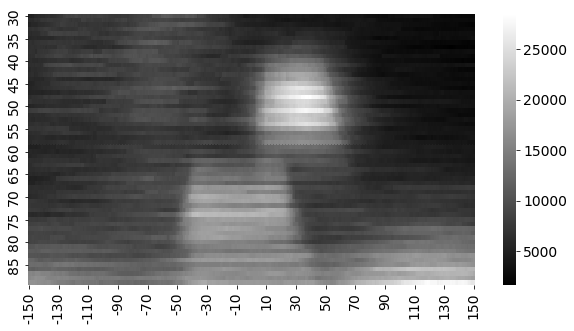

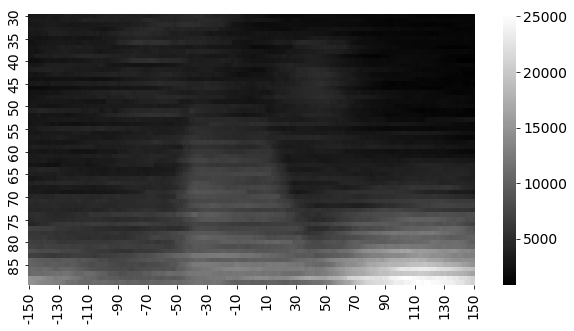

In [15]:
bin_size=1
min_size=30
max_size=90
start=-150
end=151

gt=gtf_df.loc[gtf_df['biotype']=='protein_coding']
genes=gt.loc[np.log10(gt['PRO_TR'])>1]['gid']

for condition in ['untreated','trp']:
    gene_tmp=genes_df.loc[(genes_df['gid'].isin(genes))&(genes_df['condition']==condition)]
    meta=plot_meta_heatmap(gene_tmp, start, end, min_size, max_size, bin_size)

    fig, ax=plt.subplots(1,1,figsize=(10,5))
    sns.heatmap(data=meta, cbar=True, cmap='gray', ax=ax, xticklabels=20, yticklabels=5, rasterized=True)#, vmax=20000, vmin=1000)
    
   # plt.savefig('Paper Figures Updated/Figure 1/size_enrichment/size_enrichment_'+condition+'.png')
   # plt.savefig('Paper Figures Updated/Figure 1/size_enrichment/size_enrichment_'+condition+'.pdf')
    plt.show()

# Comparison to PRO-seq/CAGE-seq

## Direct comparison to PRO-seq

smaller scale plot of both PRO-seq and footprint enrichment (PPP) on a single axis allowing direct comparison of signal

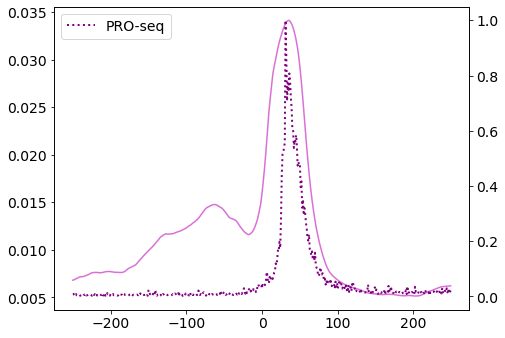

In [19]:
s=-250
e=250

conditions=['untreated']
for condition in conditions:
    #identify genes to include
    gt=gtf_df.loc[gtf_df['biotype']=='protein_coding']
    genes=gt.loc[np.log10(gt['PRO_TR'])>1]['gid']
    gene_tmp=genes_df.loc[genes_df['condition'].isin([condition])&(genes_df['gid'].isin(genes))].copy()

    fig, ax= plt.subplots(1,1,figsize=(7,5))

    #plot PRO-seq
    smooth=1
    box = np.ones(smooth)/smooth
    PRO_fwd = signal_df.loc[signal_df['dataset']=='PRO_fwd'].loc[signal_df['pos'].isin(np.arange(s-smooth,e+smooth))].loc[:,genes]
    tmp_sum = PRO_fwd.sum(axis=0)
    PRO_fwd = PRO_fwd/tmp_sum
    PRO_fwd = PRO_fwd.sum(axis=1)
    PRO_fwd = np.convolve(PRO_fwd, box, mode='same')
    PRO_fwd=PRO_fwd[smooth:len(PRO_fwd)-smooth]
    PRO_fwd = PRO_fwd/max(PRO_fwd)
    ax2 = ax.twinx() 
    ax2.plot(np.arange(s,e),PRO_fwd, color='purple', label='PRO-seq', linestyle=':', linewidth='2')
    fig.legend(loc="upper left", bbox_to_anchor=(0,1), bbox_transform=ax.transAxes)
    plt.tight_layout()

    #plot Fiber-seq
    smooth=10
    box = np.ones(smooth)/smooth
    b=meta_line_plot(gene_tmp, s-smooth, e+smooth, 40, 60, False)
    b = np.convolve(b, box, mode='same')
    b=b[smooth:len(b)-smooth]
    ax.plot(np.arange(s,e),b, color='orchid',label='Pause')


    #plt.savefig('Paper Figures Updated/Figure 1/footprint enrichment/'+condition+'_PRO_comparison.png')
   # plt.savefig('Paper Figures Updated/Figure 1/footprint enrichment/'+condition+'_PRO_comparison.pdf')

    plt.show()

## Direct comparison to CAGE-seq

smaller scale plot of both CAGE-seq and footprint enrichment (PIC) on a single axis allowing direct comparison of signal

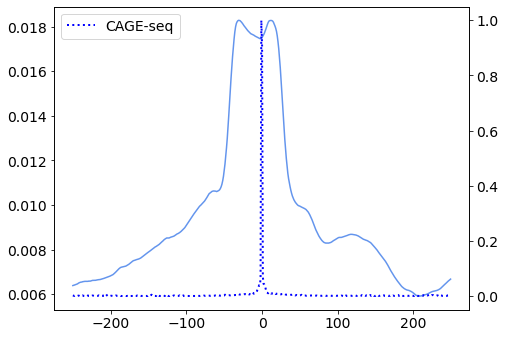

In [20]:
s=-250
e=250

for condition in ['untreated']:
    #identify genes to include
    gt=gtf_df.loc[gtf_df['biotype']=='protein_coding']
    genes=gt.loc[np.log10(gt['PRO_TR'])>1]['gid']
    gene_tmp=genes_df.loc[genes_df['condition'].isin([condition])&(genes_df['gid'].isin(genes))].copy()

    fig, ax= plt.subplots(1,1,figsize=(7,5))

    #plot CAGE-seq
    smooth=1
    box = np.ones(smooth)/smooth
    CAGE_fwd = signal_df.loc[signal_df['dataset']=='CAGE_fwd'].loc[signal_df['pos'].isin(np.arange(s-smooth,e+smooth))].loc[:,genes]
    tmp_sum = CAGE_fwd.sum(axis=0)
    CAGE_fwd = CAGE_fwd/tmp_sum
    CAGE_fwd = CAGE_fwd.sum(axis=1)
    CAGE_fwd = np.convolve(CAGE_fwd, box, mode='same')
    CAGE_fwd=CAGE_fwd[smooth:len(CAGE_fwd)-smooth]
    CAGE_fwd = CAGE_fwd/max(CAGE_fwd)
    ax2 = ax.twinx() 
    ax2.plot(np.arange(s,e),CAGE_fwd, color='blue', label='CAGE-seq', linestyle=':', linewidth='2')
    fig.legend(loc="upper left", bbox_to_anchor=(0,1), bbox_transform=ax.transAxes)
    plt.tight_layout()

    #plot Fiber-seq enrichment
    smooth=10
    box = np.ones(smooth)/smooth
    b=meta_line_plot(gene_tmp, s-smooth, e+smooth, 60, 80, False)
    b = np.convolve(b, box, mode='same')
    b=b[smooth:len(b)-smooth]
    ax.plot(np.arange(s,e),b, color='cornflowerblue',label='PIC')

   # plt.savefig('Paper Figures Updated/Figure 1/footprint enrichment/'+condition+'_CAGE_comparison.png')
    #plt.savefig('Paper Figures Updated/Figure 1/footprint enrichment/'+condition+'_CAGE_comparison.pdf')
    plt.show()

## Comparison to PRO-seq and CAGE-seq

plot of CAGE-seq, PRO-seq, and MNase-seq above and and footprint enrichment below allowing overall comparison of signals

untreated


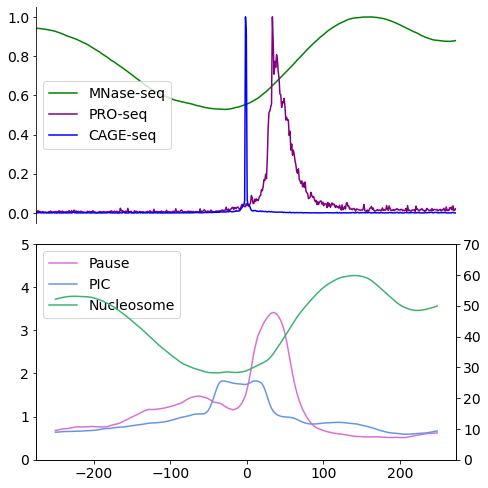

In [21]:
s=-250
e=250
smooth=10
conditions=['untreated']

#id highly paused genes
gt=gtf_df.loc[gtf_df['biotype']=='protein_coding']
genes=gt.loc[np.log10(gt['PRO_TR'])>1]['gid']

#grab different datasets
#mnase
mnase_fwd = signal_df_mnase.loc[signal_df_mnase['dataset']=='mnase_5']
mnase_fwd=mnase_fwd.loc[mnase_fwd['pos'].isin(np.arange(s,e))]
mnase_fwd=mnase_fwd.loc[:,genes]
tmp_sum = mnase_fwd.sum(axis=0)
mnase_fwd = mnase_fwd/tmp_sum
mnase_fwd = mnase_fwd.sum(axis=1)
mnase_fwd = mnase_fwd/max(mnase_fwd)

#pro-seq
PRO_fwd = signal_df.loc[signal_df['dataset']=='PRO_fwd']
PRO_fwd=PRO_fwd.loc[PRO_fwd['pos'].isin(np.arange(s,e))]
PRO_fwd=PRO_fwd.loc[:,genes]
tmp_sum = PRO_fwd.sum(axis=0)
PRO_fwd = PRO_fwd/tmp_sum
PRO_fwd = PRO_fwd.sum(axis=1)
PRO_fwd = PRO_fwd/max(PRO_fwd)

#cage-seq
CAGE_fwd = signal_df.loc[signal_df['dataset']=='CAGE_fwd']
CAGE_fwd=CAGE_fwd.loc[CAGE_fwd['pos'].isin(np.arange(s,e))]
CAGE_fwd=CAGE_fwd.loc[:,genes]
tmp_sum = CAGE_fwd.sum(axis=0)
CAGE_fwd = CAGE_fwd/tmp_sum
CAGE_fwd = CAGE_fwd.sum(axis=1)
CAGE_fwd = CAGE_fwd/max(CAGE_fwd)


for condition in conditions:
    print(condition)
    #filter genes_df
    gene_tmp=genes_df.loc[genes_df['condition'].isin([condition])&(genes_df['gid'].isin(genes))]

    #plot other datasets
    fig, ax= plt.subplots(2,1,figsize=(7,7),gridspec_kw={'height_ratios': [1,1]})
    ax[0].plot(np.arange(s,e),mnase_fwd, color='green', label='MNase-seq')
    ax[0].plot(np.arange(s,e),PRO_fwd, color='purple', label='PRO-seq')
    ax[0].plot(np.arange(s,e),CAGE_fwd, color='blue', label='CAGE-seq')
    ax[0].set_xlim(s,e)
    ax[0].legend(loc='center left')
    ax[0].set_xticks([])
    ax[0].spines['top'].set_visible(False)
    ax[0].spines['right'].set_visible(False)
    ax[0].spines['bottom'].set_visible(False)

    #generate Fiber-seq enrichment
    b=meta_line_plot(gene_tmp, s-smooth, e+smooth, 40, 60, False)
    c=meta_line_plot(gene_tmp, s-smooth, e+smooth, 60, 80, False)
    d=meta_line_plot(gene_tmp, s-smooth, e+smooth, 90, 300, False)

    #smoothing
    box = np.ones(smooth)/smooth
    b = np.convolve(b, box, mode='same')
    b=b[smooth:len(b)-smooth]
    c = np.convolve(c, box, mode='same')
    c=c[smooth:len(c)-smooth]        
    d = np.convolve(d, box, mode='same')
    d=d[smooth:len(d)-smooth]

    #plot Fiber-seq enrichment
    l1 = ax[1].plot(np.arange(s,e),b*100, color='orchid',label='Pause')
    l2 = ax[1].plot(np.arange(s,e),c*100, color='cornflowerblue',label='PIC')
    ax3 = ax[1].twinx() 
    l3 = ax3.plot(np.arange(s,e),d*100, color='mediumseagreen',label='Nucleosome')
    ls = l1+l2+l3
    labs = [l.get_label() for l in ls]
    ax[1].legend(ls, labs, loc='upper left')
    ax3.set_ylim(0,70)
    ax[1].set_ylim(0,5)

    #save plot
    plt.tight_layout()
    #plt.savefig('Paper Figures Updated/Figure 1/footprint enrichment/'+condition+'_footprint_enrichment.png')
   # plt.savefig('Paper Figures Updated/Figure 1/footprint enrichment/'+condition+'_footprint_enrichment.pdf')
    plt.show()


# Pause index, expression

## Pause index

histogram of distribution of pause index across genes

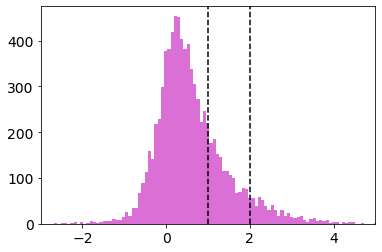

In [22]:
#plot pause index distribution
gl=[]
start=20
end=40
min_size=40
max_size=60

gt=gtf_df.loc[gtf_df['biotype']=='protein_coding']
gs=genes_df.loc[genes_df.loc[:,np.arange(start,end).astype(str)].isin(np.arange(min_size,max_size)).any(axis=1)]

gl.append(gt.loc[np.log10(gt['PRO_TR'])<1]['gid'])
gl.append(gt.loc[np.log10(gt['PRO_TR'])<2].loc[np.log10(gt['PRO_TR'])>1]['gid'])
gl.append(gt.loc[np.log10(gt['PRO_TR'])>2]['gid'])

plt.hist(np.log10(gt['PRO_TR']), bins=100, color='orchid')
plt.plot([1,1],[0,500], '--', color='black')
plt.plot([2,2],[0,500], '--',color='black')
plt.xlim(-3,5)
plt.ylim(0,475)
#plt.savefig('Paper Figures Updated/Figure 1/PI + expression/PI_cutoffs.png')
#plt.savefig('Paper Figures Updated/Figure 1/PI + expression/PI_cutoffs.pdf')
plt.show()

### overall enrichment

enrichment of PPP footprints at different pause index cutoffs

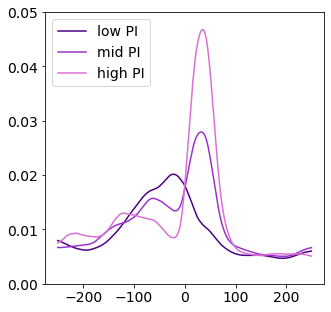

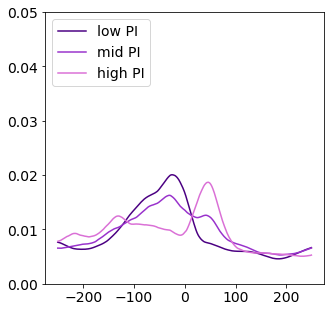

In [23]:
s=-250
e=250
smooth=25

for condition in ['untreated','trp']:
    i=0
    fig, ax= plt.subplots(1,1,figsize=(5,5))
    colors=['indigo', 'darkorchid','orchid']
    labels=['low PI', 'mid PI', 'high PI']
    for genes in gl:

        gene_tmp=genes_df.loc[genes_df['condition'].isin([condition])&(genes_df['gid'].isin(genes))].copy()

        b=meta_line_plot(gene_tmp,  s-smooth, e+smooth, 40, 60, False)

        box = np.ones(smooth)/smooth
        b = np.convolve(b, box, mode='same')
        b = b[smooth:len(b)-smooth]

        ax.plot(np.arange(s,e),b, color=colors[i], label=labels[i])

        ax.legend(loc='upper left')
        ax.set_ylim(0,.05)

        i+=1

  #  plt.savefig('Paper Figures Updated/Figure 1/PI + expression/'+condition+'_footprint_enrichment_PI.png')
   # plt.savefig('Paper Figures Updated/Figure 1/PI + expression/'+condition+'_footprint_enrichment_PI.pdf')
    plt.show()


enrichment of PPP footprints at different pause index cutoffs (only reads with NDR)

In [57]:
start=-20
end=20
min_size=80
max_size=10000
ndr_reads=genes_df.loc[~genes_df.loc[:,np.arange(start,end).astype(str)].isin(np.arange(min_size,max_size)).any(axis=1)]

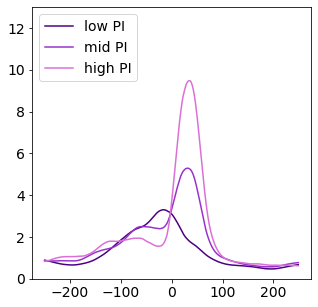

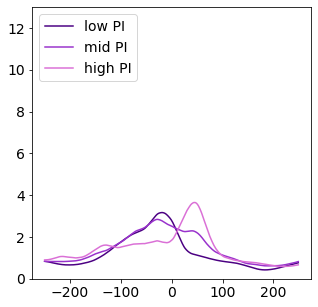

In [25]:
s=-250
e=250
smooth=25

for condition in ['untreated','trp']:
    i=0
    fig, ax= plt.subplots(1,1,figsize=(5,5))
    colors=['indigo', 'darkorchid','orchid']
    labels=['low PI', 'mid PI', 'high PI']
    for genes in gl:

        gene_tmp=ndr_reads.loc[ndr_reads['condition'].isin([condition])&(ndr_reads['gid'].isin(genes))].copy()

        b=meta_line_plot(gene_tmp,  s-smooth, e+smooth, 40, 60, False)

        box = np.ones(smooth)/smooth
        b = np.convolve(b, box, mode='same')
        b = b[smooth:len(b)-smooth]

        ax.plot(np.arange(s,e),b*100, color=colors[i], label=labels[i])

        ax.legend(loc='upper left')
        ax.set_ylim(0,13)

        i+=1

   # plt.savefig('Paper Figures Updated/Figure 1/PI + expression/'+condition+'_footprint_enrichment_PI_ndr.png')
   # plt.savefig('Paper Figures Updated/Figure 1/PI + expression/'+condition+'_footprint_enrichment_PI_ndr.pdf')
    plt.show()


enrichment of PIC footprints at different pause index cutoffs (only reads with NDR)

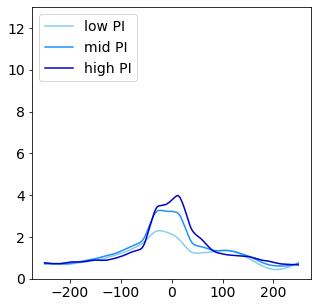

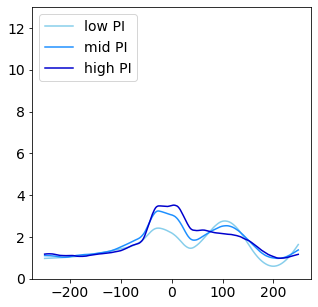

In [27]:
s=-250
e=250
smooth=25

for condition in ['untreated','trp']:
    i=0
    fig, ax= plt.subplots(1,1,figsize=(5,5))
    colors=['skyblue', 'dodgerblue', 'mediumblue']
    labels=['low PI', 'mid PI', 'high PI']
    for genes in gl:

        gene_tmp=ndr_reads.loc[ndr_reads['condition'].isin([condition])&(ndr_reads['gid'].isin(genes))].copy()

        b=meta_line_plot(gene_tmp,  s-smooth, e+smooth, 61, 80, False)

        box = np.ones(smooth)/smooth
        b = np.convolve(b, box, mode='same')
        b = b[smooth:len(b)-smooth]

        ax.plot(np.arange(s,e),b*100, color=colors[i], label=labels[i])

        ax.legend(loc='upper left')
        ax.set_ylim(0,13)

        i+=1

 #   plt.savefig('Paper Figures Updated/Figure 1/PI + expression/'+condition+'_footprint_enrichment_PI_ndr_PIC.png')
  #  plt.savefig('Paper Figures Updated/Figure 1/PI + expression/'+condition+'_footprint_enrichment_PI_ndr_PIC.pdf')
    plt.show()


### per gene

In [51]:
#import new data (processed, coding)
s=-550
e=550
genes_df=pd.DataFrame()
for f in os.listdir('/mnt/d/Processed'):
    if 'untreated' in f and '_coding' in f:
#    if 'naked' not in f and 'hia5' and 'dmso' not in f and 'noncoding' not in f:
        print(f)
        tmp=pd.read_csv('/mnt/d/Processed/'+f, sep='\t', usecols=np.append(['gid','rid','condition','dataset'],np.arange(s,e).astype(str)))#, nrows=3)
        tmp=tmp.loc[tmp['gid'].isin(gtf_df.dropna(subset='PRO_TR')['gid'])]
        tmp=tmp.dropna()
        tmp=tmp.loc[~tmp.isin([2.0]).any(axis=1)]
        genes_df=pd.concat([tmp, genes_df], axis=0)
genes_df.columns=genes_df.columns.astype(str)
#import new data (processed, coding)

2000-2000_coding_untreated_1.tsv
2000-2000_coding_untreated_2.tsv
2000-2000_coding_untreated_3.tsv
2000-2000_coding_untreated_4.tsv
2000-2000_coding_untreated_5.tsv
2000-2000_coding_untreated_6.tsv
2000-2000_coding_untreated_7.tsv


In [ ]:
#calling PPP and PIC footprints

s=-550
e=550

start=-20
end=20
min_size=90
max_size=10000
# call_peaks(signal_df, gtf_df, dataset, min_pos, max_pos, window_size, min_threshold,min_cov,plot):

#reads with NDR first
print('ndr reads')
ndr_reads=genes_df.loc[~genes_df.loc[:,np.arange(start,end).astype(str)].isin(np.arange(min_size,max_size)).any(axis=1)]
#genes_df=[]
ndr_reads=ndr_reads.drop(['dataset'], axis=1).fillna(0)
print('peaks')

#call peaks in PRO-seq data
pro_peaks=call_peaks(signal_df, gtf_df, 'PRO_fwd', 0, 100, 20, 10, 20, 1)
cage_peaks=call_peaks(signal_df, gtf_df, 'CAGE_fwd', -50, 50, 20, 10,20, 1)
ndr_reads['rid,gid']=ndr_reads['rid']+','+ndr_reads['gid']

#call overlapping PPP footprints
print('hits pause')
hits, nohits_pause=call_hits(ndr_reads, 40, 60, 1/.15, pro_peaks, s)
print(len(hits), len(nohits_pause))
pause_reads=ndr_reads.loc[ndr_reads['rid,gid'].isin(hits)]

#call overlapping PIC footprints
print('hits pic')
hits, nohits_pic=call_hits(ndr_reads, 61, 80, 1/.15, cage_peaks, s)
print(len(hits), len(nohits_pic))
pic_reads=ndr_reads.loc[ndr_reads['rid,gid'].isin(hits)]

In [30]:
#count PPP and PIC footprints for each gene

pic_g={}
ppp_g={}
ndr_g={}
all_g={}
i=0
for gid in genes_df['gid'].unique():
    pic_g[gid]=pic_reads.loc[pic_reads['gid']==gid].shape[0]
    ppp_g[gid]=pause_reads.loc[pause_reads['gid']==gid].shape[0]
    ndr_g[gid]=ndr_reads.loc[ndr_reads['gid']==gid].shape[0]
    all_g[gid]=genes_df.loc[genes_df['gid']==gid].shape[0]
    i+=1
    if i%1000==0:
        print(i)

gtf_df['pic_ct']=gtf_df['gid'].map(pic_g)
gtf_df['ppp_ct']=gtf_df['gid'].map(ppp_g)
gtf_df['ndr_ct']=gtf_df['gid'].map(ndr_g)
gtf_df['all_ct']=gtf_df['gid'].map(all_g)

1000
2000
3000
4000
5000
6000
7000
8000


boxenplot of PPP or PIC footprint percent across genes, or NDR percent (reads with NDR)

In [36]:
#annotate pause index bins
gl=[]
cat=[]
gt=gtf_df.loc[gtf_df['biotype']=='protein_coding']
gl+=(gt.loc[np.log10(gt['PRO_TR'])<1]['gid'].tolist())
cat+=(['low']*len(gt.loc[np.log10(gt['PRO_TR'])<=1]['gid']))
gl+=(gt.loc[np.log10(gt['PRO_TR'])<2].loc[np.log10(gt['PRO_TR'])>1]['gid'].tolist())
cat+=(['mid']*len(gt.loc[np.log10(gt['PRO_TR'])<=2].loc[np.log10(gt['PRO_TR'])>1]['gid']))
gl+=gt.loc[np.log10(gt['PRO_TR'])>2]['gid'].tolist()
cat+=['high']*len(gt.loc[np.log10(gt['PRO_TR'])>2]['gid'])
gtf_df['PI_bin']=gtf_df['gid'].map(dict(zip(gl, cat)))

#remove genes with no pause index
gt=gtf_df.dropna(subset='PI_bin')[['PI_bin','ndr_ct','all_ct','pic_ct','ppp_ct', 'PRO_TR']]
gt['ppp_percent']=(gt['ppp_ct']/gt['ndr_ct'])*100
gt['pic_percent']=(gt['pic_ct']/gt['ndr_ct'])*100
gt['ndr_percent']=(gt['ndr_ct']/gt['all_ct'])*100

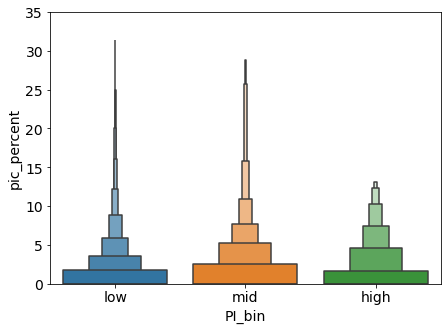

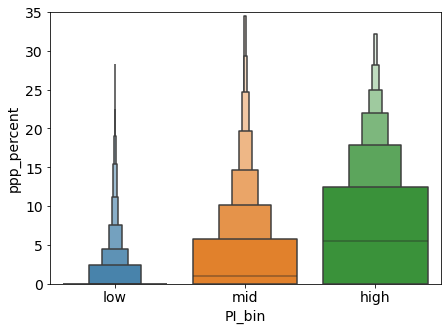

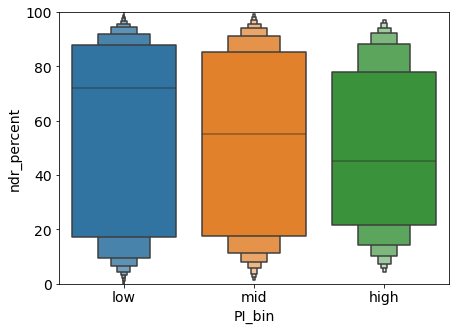

low ppp
0.9609424295972689
low pic
1.403601076248058
low ndr
56.66660853642304
mid ppp
3.8960487227572487
mid pic
1.9771107599058841
mid ndr
51.870257670419534
high ppp
7.586147965589225
high pic
1.4717831045910952
high ndr
48.91302648998832


In [39]:
plt.figure(figsize=(7,5))
sns.boxenplot(data=gt.loc[(gt['pic_percent']>=0)],y='pic_percent', x='PI_bin', scale='exponential', showfliers=False)#, log_scale=True)#,multiple="dodge")
plt.ylim(0,35)
#plt.savefig('Paper Figures Updated/Figure 1/PI + expression/PI_boxen_PPP.png')
#plt.savefig('Paper Figures Updated/Figure 1/PI + expression/PI_boxen_PPP.pdf')
plt.show()


plt.figure(figsize=(7,5))
sns.boxenplot(data=gt.loc[(gt['ppp_percent']>=0)],y='ppp_percent', x='PI_bin', scale='exponential', showfliers=False)
plt.ylim(0,35)
#plt.savefig('Paper Figures Updated/Figure 1/PI + expression/PI_boxen_PIC.png')
#plt.savefig('Paper Figures Updated/Figure 1/PI + expression/PI_boxen_PIC.pdf')
plt.show()

plt.figure(figsize=(7,5))
sns.boxenplot(data=gt.loc[(gt['ndr_percent']>=0)],y='ndr_percent', x='PI_bin', scale='exponential', showfliers=False)
plt.ylim(0,100)
#plt.savefig('Paper Figures Updated/Figure 1/PI + expression/PI_boxen_NDR.png')
#plt.savefig('Paper Figures Updated/Figure 1/PI + expression/PI_boxen_NDR.pdf')
plt.show()


for pi in gt['PI_bin'].unique():
    print(pi, 'ppp')
    print(np.mean(gt.loc[gt['PI_bin']==pi]['ppp_percent']))
    print(pi, 'pic')
    print(np.mean(gt.loc[gt['PI_bin']==pi]['pic_percent']))
    print(pi, 'ndr')
    print(np.mean(gt.loc[gt['PI_bin']==pi]['ndr_percent']))


boxenplot of PPP or PIC footprint percent across genes (all reads)

In [40]:
#annotate pause index bins
gl=[]
cat=[]
gt=gtf_df.loc[gtf_df['biotype']=='protein_coding']
gl+=(gt.loc[np.log10(gt['PRO_TR'])<1]['gid'].tolist())
cat+=(['low']*len(gt.loc[np.log10(gt['PRO_TR'])<=1]['gid']))
gl+=(gt.loc[np.log10(gt['PRO_TR'])<2].loc[np.log10(gt['PRO_TR'])>1]['gid'].tolist())
cat+=(['mid']*len(gt.loc[np.log10(gt['PRO_TR'])<=2].loc[np.log10(gt['PRO_TR'])>1]['gid']))
gl+=gt.loc[np.log10(gt['PRO_TR'])>2]['gid'].tolist()
cat+=['high']*len(gt.loc[np.log10(gt['PRO_TR'])>2]['gid'])
gtf_df['PI_bin']=gtf_df['gid'].map(dict(zip(gl, cat)))

#remove genes with no pause index
gt=gtf_df.dropna(subset='PI_bin')[['PI_bin','ndr_ct','all_ct','pic_ct','ppp_ct', 'PRO_TR']]
gt['ppp_percent']=(gt['ppp_ct']/gt['all_ct'])*100
gt['pic_percent']=(gt['pic_ct']/gt['all_ct'])*100

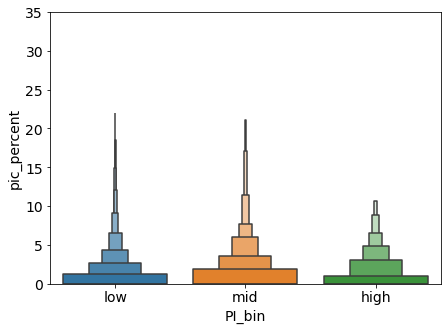

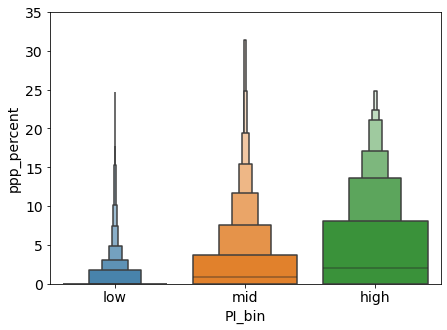

low ppp
0.6839176072787527
low pic
1.0702858349898021
mid ppp
2.864053016264638
mid pic
1.4334584039989953
high ppp
5.005091898809599
high pic
1.0100534501584146


In [41]:
plt.figure(figsize=(7,5))
sns.boxenplot(data=gt.loc[(gt['pic_percent']>=0)],y='pic_percent', x='PI_bin', scale='exponential', showfliers=False)#, log_scale=True)#,multiple="dodge")
plt.ylim(0,35)
#plt.savefig('Paper Figures Updated/Figure 1/PI + expression/PI_boxen_PPP.png')
#plt.savefig('Paper Figures Updated/Figure 1/PI + expression/PI_boxen_PPP.pdf')
plt.show()


plt.figure(figsize=(7,5))
sns.boxenplot(data=gt.loc[(gt['ppp_percent']>=0)],y='ppp_percent', x='PI_bin', scale='exponential', showfliers=False)
plt.ylim(0,35)
#plt.savefig('Paper Figures Updated/Figure 1/PI + expression/PI_boxen_PIC.png')
#plt.savefig('Paper Figures Updated/Figure 1/PI + expression/PI_boxen_PIC.pdf')
plt.show()


for pi in gt['PI_bin'].unique():
    print(pi, 'ppp')
    print(np.mean(gt.loc[gt['PI_bin']==pi]['ppp_percent']))
    print(pi, 'pic')
    print(np.mean(gt.loc[gt['PI_bin']==pi]['pic_percent']))

## Expression

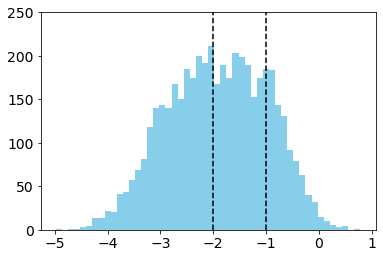

In [47]:
gtf_df=pd.read_csv('Reference Files/dm6/dm6_info.csv', sep='\t')
gt=gtf_df.loc[gtf_df['biotype']=='protein_coding']
plt.hist(np.log10(gt.loc[gt['PRO_body']>0]['PRO_body']), bins=50, color='skyblue')
plt.plot([-2,-2],[0,250], '--', color='black')
plt.plot([-1,-1],[0,250], '--', color='black')
plt.ylim(0,250)
plt.savefig('Paper Figures Updated/Figure 1/PI + expression/expression_cutoffs.png')
plt.savefig('Paper Figures Updated/Figure 1/PI + expression/expression_cutoffs.pdf')
plt.show()

gl=[]
start=20
end=40
min_size=40
max_size=60

gt=gtf_df.loc[gtf_df['biotype']=='protein_coding']
gs=genes_df.loc[genes_df.loc[:,np.arange(start,end).astype(str)].isin(np.arange(min_size,max_size)).any(axis=1)]

gl.append(gt.loc[np.log10(gt['PRO_body'])<-2]['gid'])
gl.append(gt.loc[np.log10(gt['PRO_body'])<-1].loc[np.log10(gt['PRO_body'])>=-2]['gid'])
gl.append(gt.loc[np.log10(gt['PRO_body'])>=-1]['gid'])

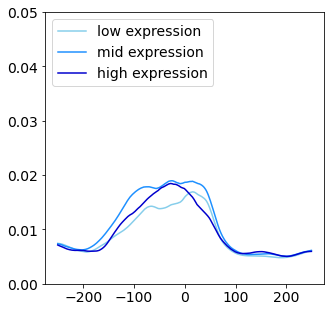

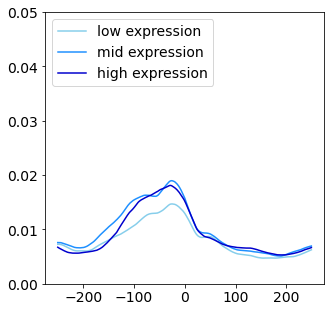

In [55]:
s=-250
e=250
smooth=25

for condition in ['untreated','trp']:
    i=0
    fig, ax= plt.subplots(1,1,figsize=(5,5))
    colors=['skyblue', 'dodgerblue', 'mediumblue']
    labels=['low expression', 'mid expression', 'high expression']
    for genes in gl:

        gene_tmp=genes_df.loc[genes_df['condition'].isin([condition])&(genes_df['gid'].isin(genes))].copy()
        b=meta_line_plot(gene_tmp,  s-smooth, e+smooth, 40, 60, False)

        box = np.ones(smooth)/smooth
        b = np.convolve(b, box, mode='same')
        b = b[smooth:len(b)-smooth]

        ax.plot(np.arange(s,e),b, color=colors[i], label=labels[i])

        ax.legend(loc='upper left')
        ax.set_ylim(0,.05)

        i+=1

   # plt.savefig('Paper Figures Updated/Figure 1/PI + expression/'+condition+'_footprint_enrichment_exp.png')
    #plt.savefig('Paper Figures Updated/Figure 1/PI + expression/'+condition+'_footprint_enrichment_exp.pdf')
    plt.show()


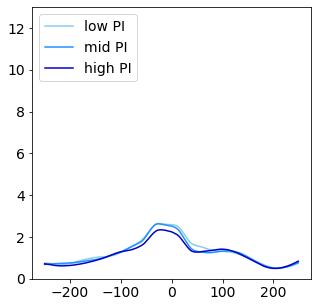

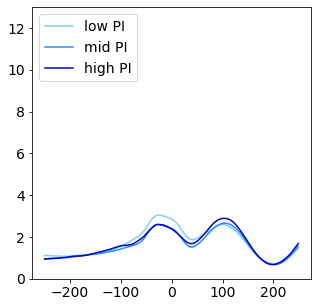

In [58]:
s=-250
e=250
smooth=25

for condition in ['untreated','trp']:
    i=0
    fig, ax= plt.subplots(1,1,figsize=(5,5))
    colors=['skyblue', 'dodgerblue', 'mediumblue']
    labels=['low PI', 'mid PI', 'high PI']
    for genes in gl:

        gene_tmp=ndr_reads.loc[ndr_reads['condition'].isin([condition])&(ndr_reads['gid'].isin(genes))].copy()

        b=meta_line_plot(gene_tmp,  s-smooth, e+smooth, 61, 80, False)

        box = np.ones(smooth)/smooth
        b = np.convolve(b, box, mode='same')
        b = b[smooth:len(b)-smooth]

        ax.plot(np.arange(s,e),b*100, color=colors[i], label=labels[i])

        ax.legend(loc='upper left')
        ax.set_ylim(0,13)

        i+=1

    #plt.savefig('Paper Figures Updated/Figure 1/PI + expression/'+condition+'_footprint_enrichment_exp_ndr_PIC.png')
   # plt.savefig('Paper Figures Updated/Figure 1/PI + expression/'+condition+'_footprint_enrichment_exp_ndr_PIC.pdf')
    plt.show()


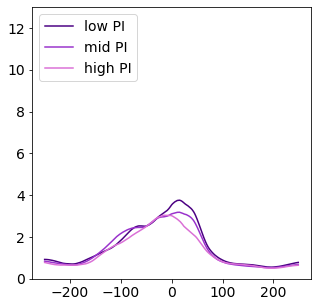

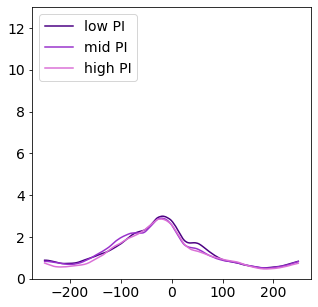

In [59]:
s=-250
e=250
smooth=25

for condition in ['untreated','trp']:
    i=0
    fig, ax= plt.subplots(1,1,figsize=(5,5))
    colors=['indigo', 'darkorchid','orchid']
    labels=['low PI', 'mid PI', 'high PI']
    for genes in gl:

        gene_tmp=ndr_reads.loc[ndr_reads['condition'].isin([condition])&(ndr_reads['gid'].isin(genes))].copy()

        b=meta_line_plot(gene_tmp,  s-smooth, e+smooth, 40, 60, False)

        box = np.ones(smooth)/smooth
        b = np.convolve(b, box, mode='same')
        b = b[smooth:len(b)-smooth]

        ax.plot(np.arange(s,e),b*100, color=colors[i], label=labels[i])

        ax.legend(loc='upper left')
        ax.set_ylim(0,13)

        i+=1

    #plt.savefig('Paper Figures Updated/Figure 1/PI + expression/'+condition+'_footprint_enrichment_PI_ndr_PPP.png')
   # plt.savefig('Paper Figures Updated/Figure 1/PI + expression/'+condition+'_footprint_enrichment_PI_ndr_PPP.pdf')
    plt.show()


# Perturbation Comparisons

In [60]:
genes_df= import_data(['untreated','trp'], '_coding', -300, 300)

2000-2000_coding_untreated_1.tsv
2000-2000_coding_untreated_2.tsv
2000-2000_coding_untreated_3.tsv
2000-2000_coding_untreated_4.tsv
2000-2000_coding_untreated_5.tsv
2000-2000_coding_untreated_6.tsv
2000-2000_coding_untreated_7.tsv
2000-2000_coding_trp_1.tsv
2000-2000_coding_trp_2.tsv
2000-2000_coding_trp_3.tsv


direct comparison of triptolide and untreated

0.014452300327486529
0.03328919509713186


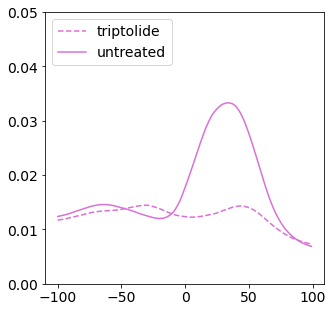

0.018649885985389924
0.018024065087962653


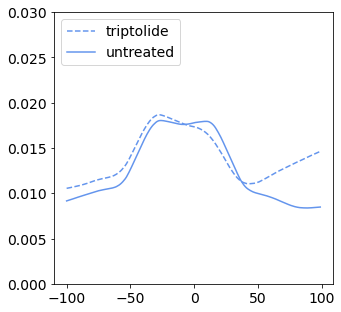

In [61]:
comparison_plot(-100, 100, 40, 60, 25, ['trp','untreated'], ['dashed', 'solid'], ['triptolide','untreated'], 'Paper Figures Updated/Figure 1/perturbations/PPP_compare_','orchid',.05)
comparison_plot(-100, 100, 60, 80, 25,['trp','untreated'], ['dashed', 'solid'], ['triptolide','untreated'], 'Paper Figures Updated/Figure 1/perturbations/PIC_compare_', 'cornflowerblue',.03)

# Example loci

In [7]:
def import_data(conditions, coding, s, e):
    genes_df=pd.DataFrame()
    for condition in conditions:
        for f in os.listdir('/mnt/d/Processed'):
            if condition in f and coding in f:
                print(f)
                tmp=pd.read_csv('/mnt/d/Processed/'+f, sep='\t', usecols=np.append(['gid','rid','condition','dataset'],np.arange(s,e).astype(str)))# 
                genes_df=pd.concat([tmp, genes_df], axis=0)
    return genes_df

genes_df= import_data(['untreated'], '_coding', -550, 550)

2000-2000_coding_untreated_1.tsv
2000-2000_coding_untreated_2.tsv
2000-2000_coding_untreated_3.tsv
2000-2000_coding_untreated_4.tsv
2000-2000_coding_untreated_5.tsv
2000-2000_coding_untreated_6.tsv
2000-2000_coding_untreated_7.tsv


In [9]:
start=-20
end=20
min_size=80
max_size=10000
condition='untreated'

pro_peaks=call_peaks(signal_df, gtf_df, 'PRO_fwd', 20, 350, 20, 20, 5, 0)
cage_peaks=call_peaks(signal_df, gtf_df, 'CAGE_fwd', -50, 50, 30, 20,5, 0)

FBgn0031745


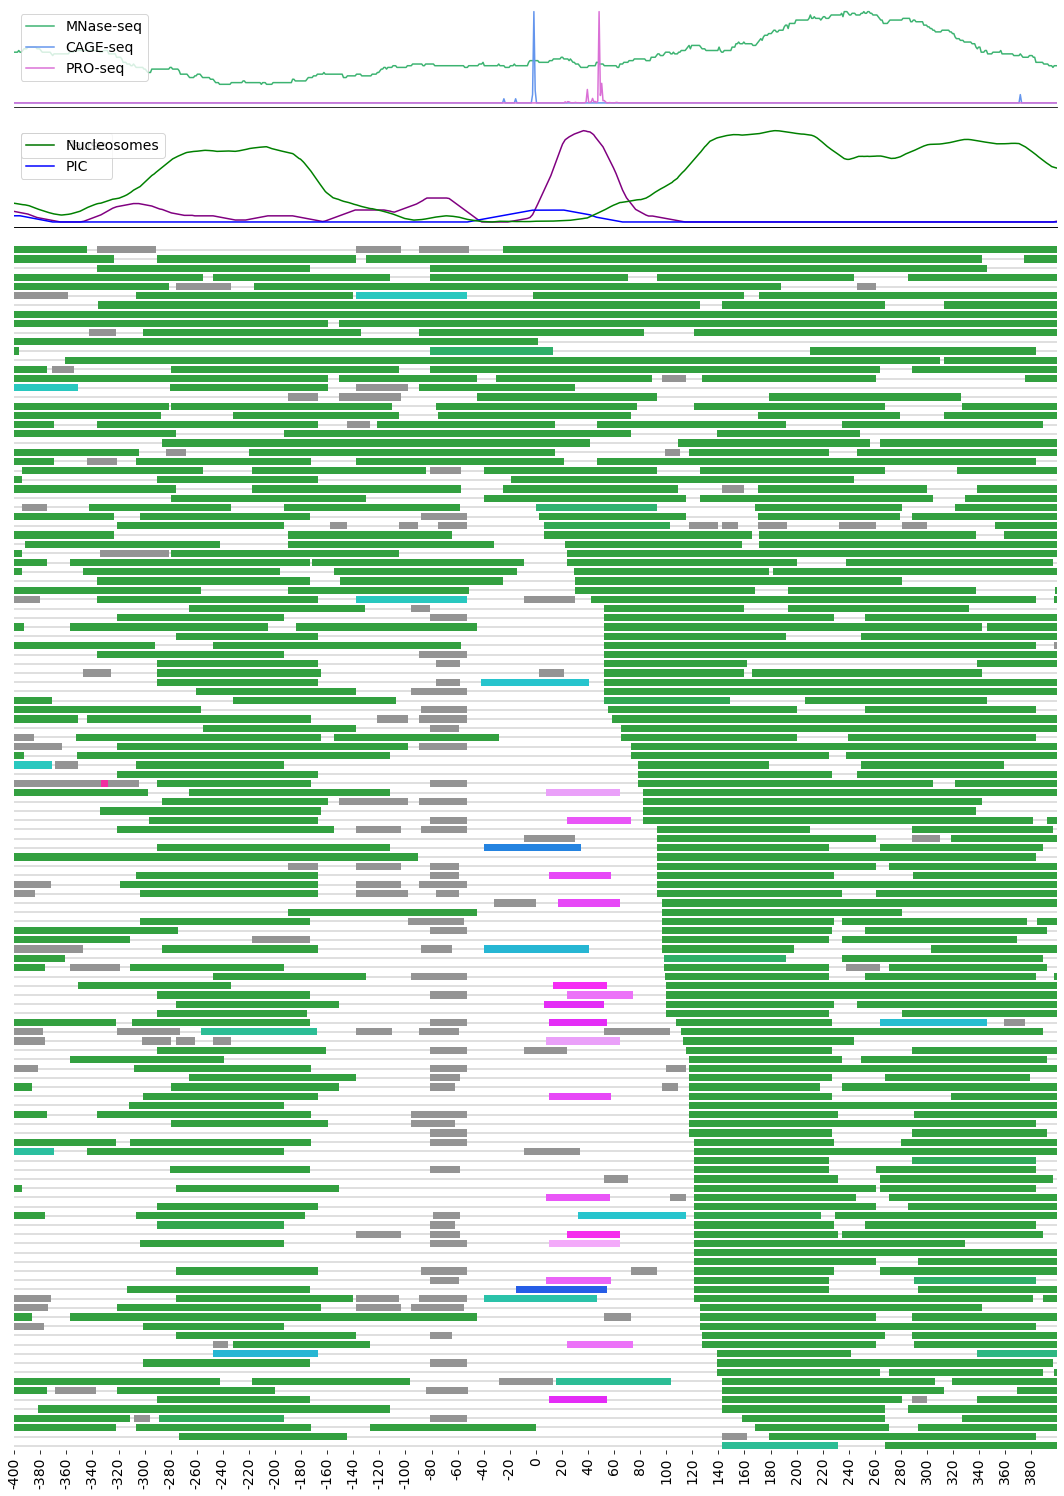

FBgn0051955


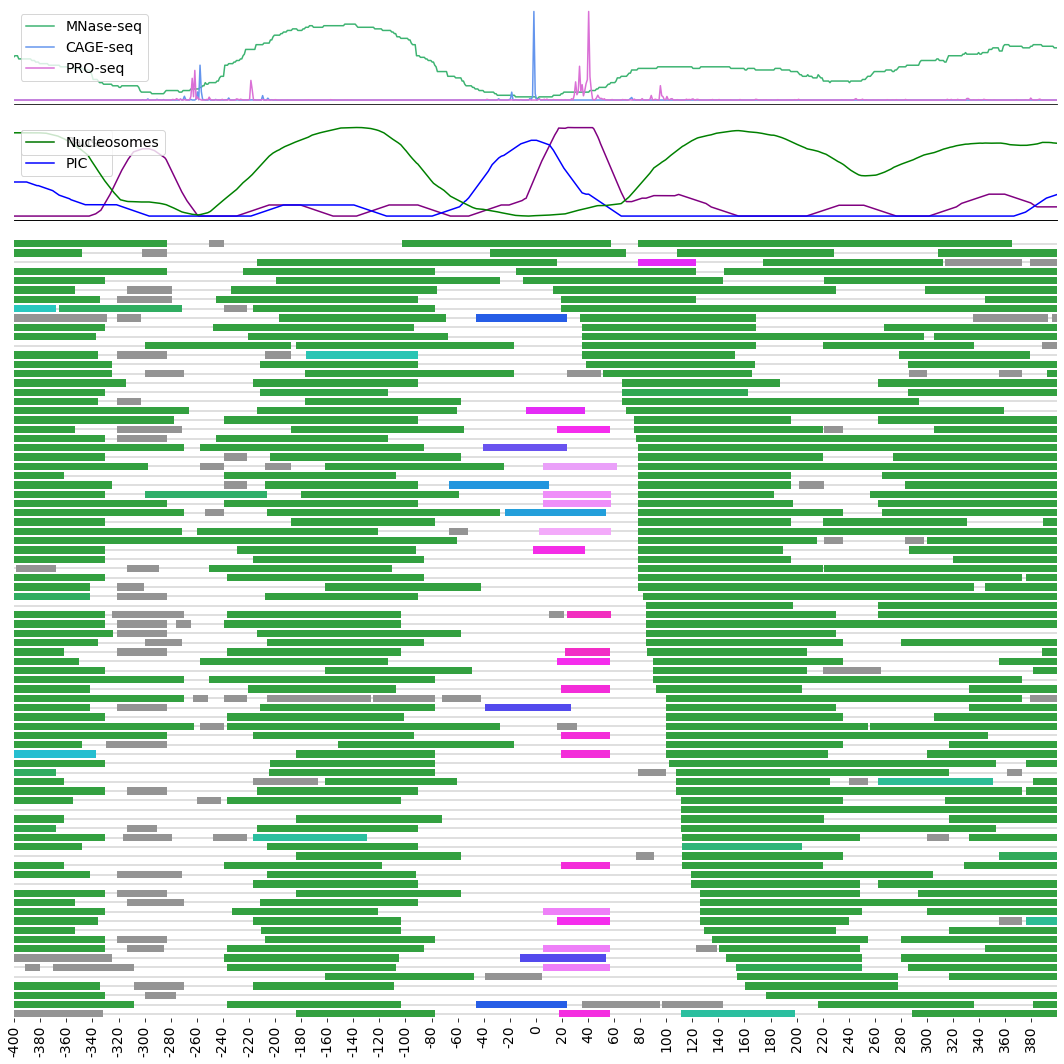

FBgn0003278


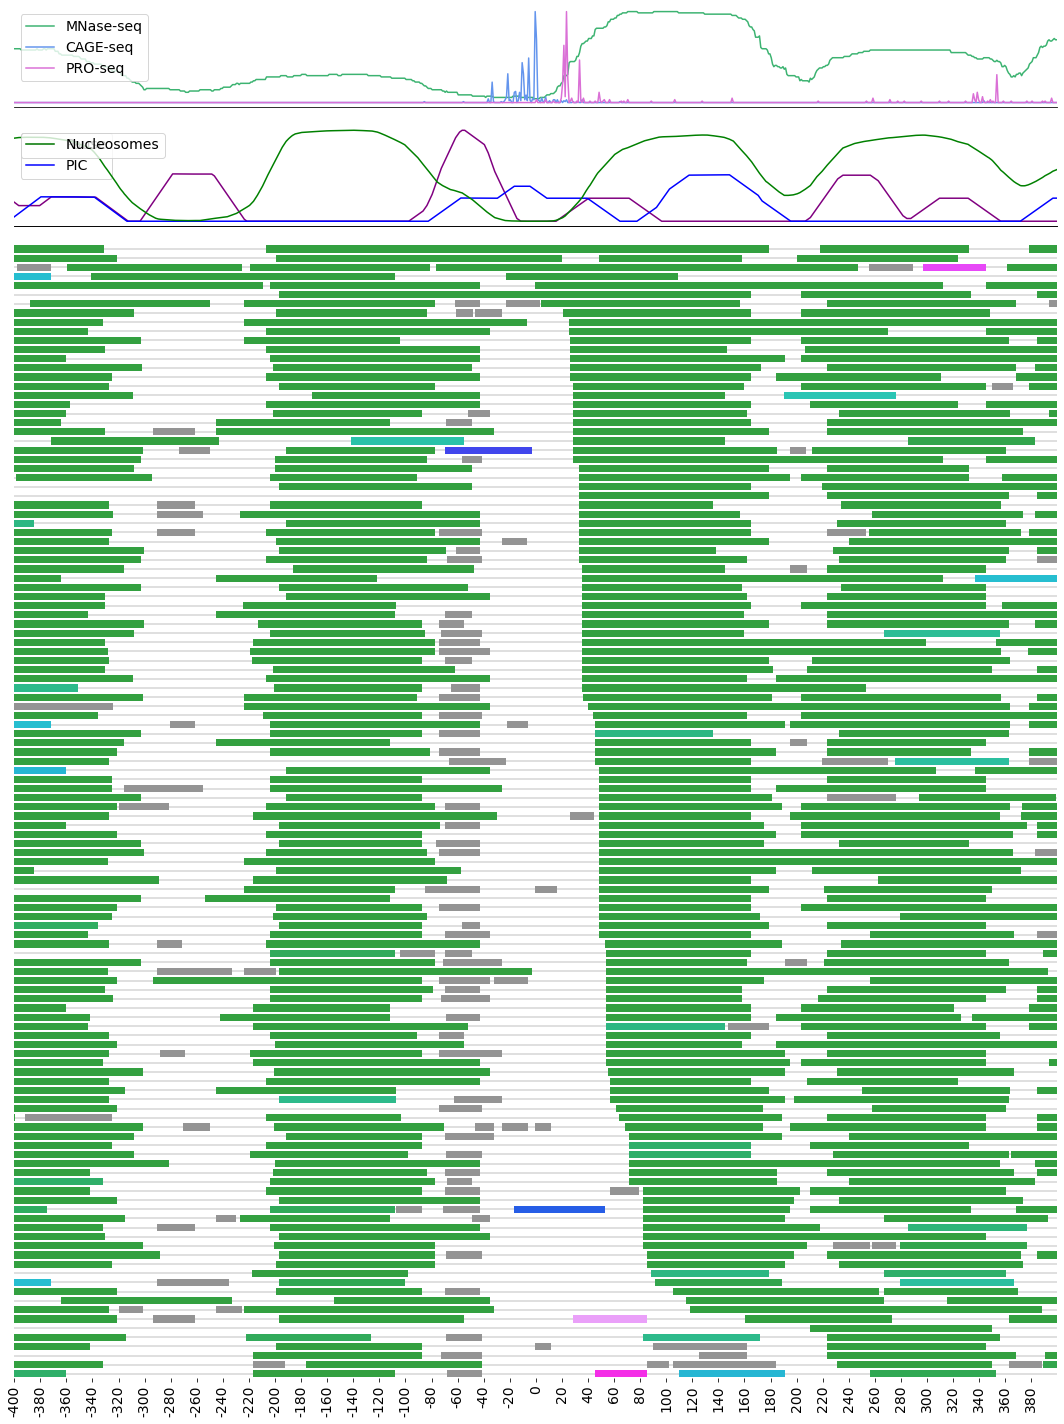

FBgn0001142


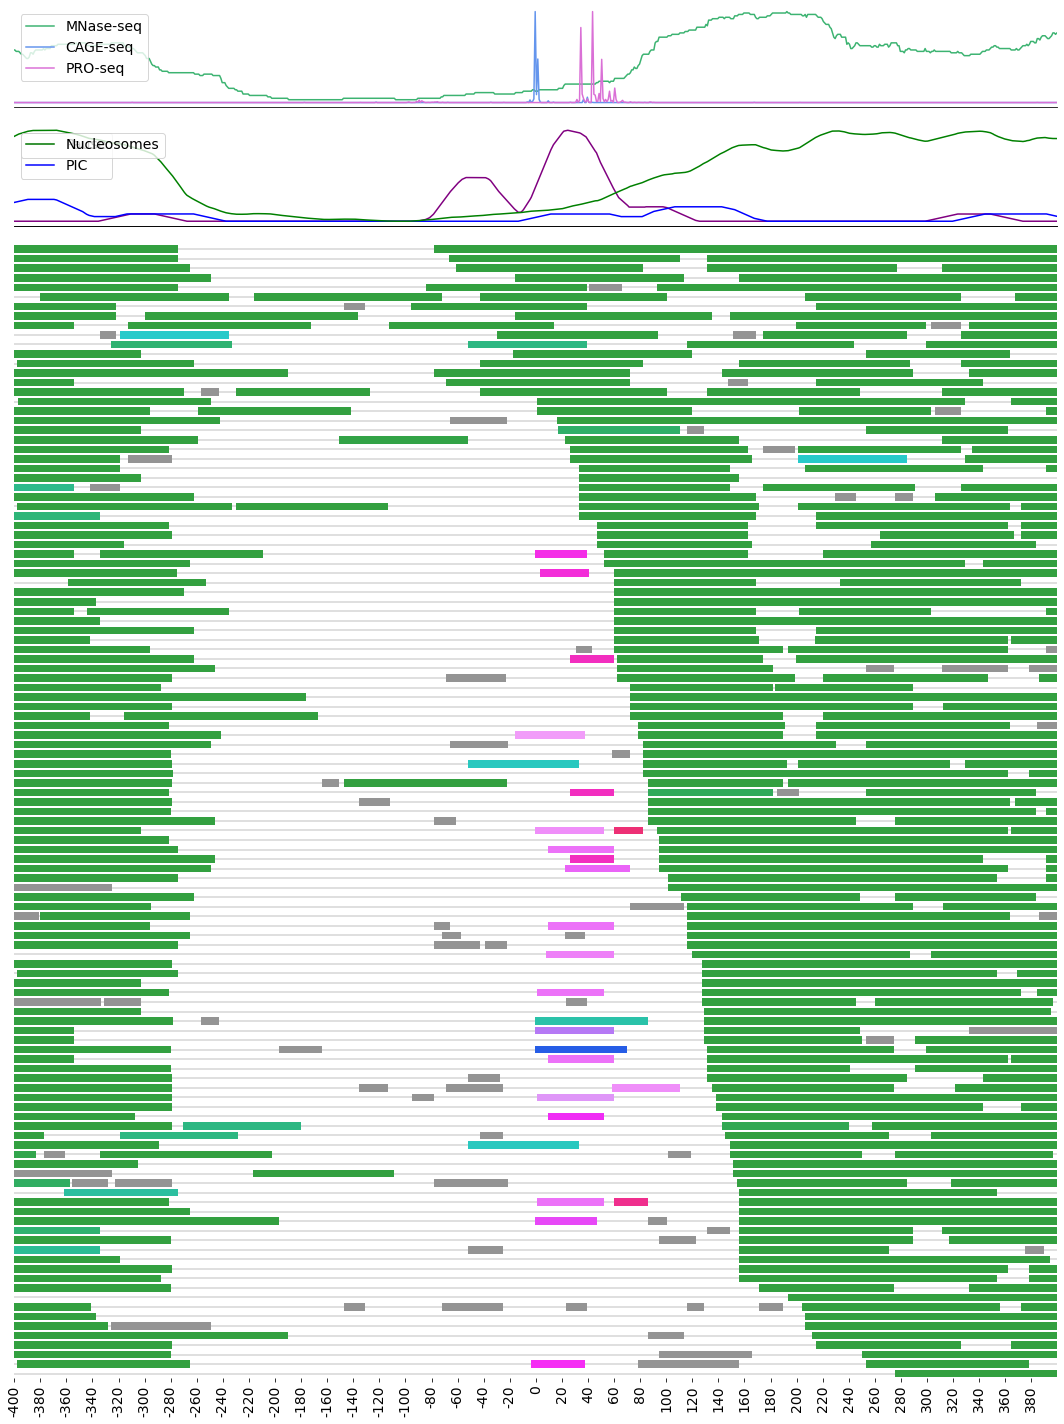

FBgn0002543


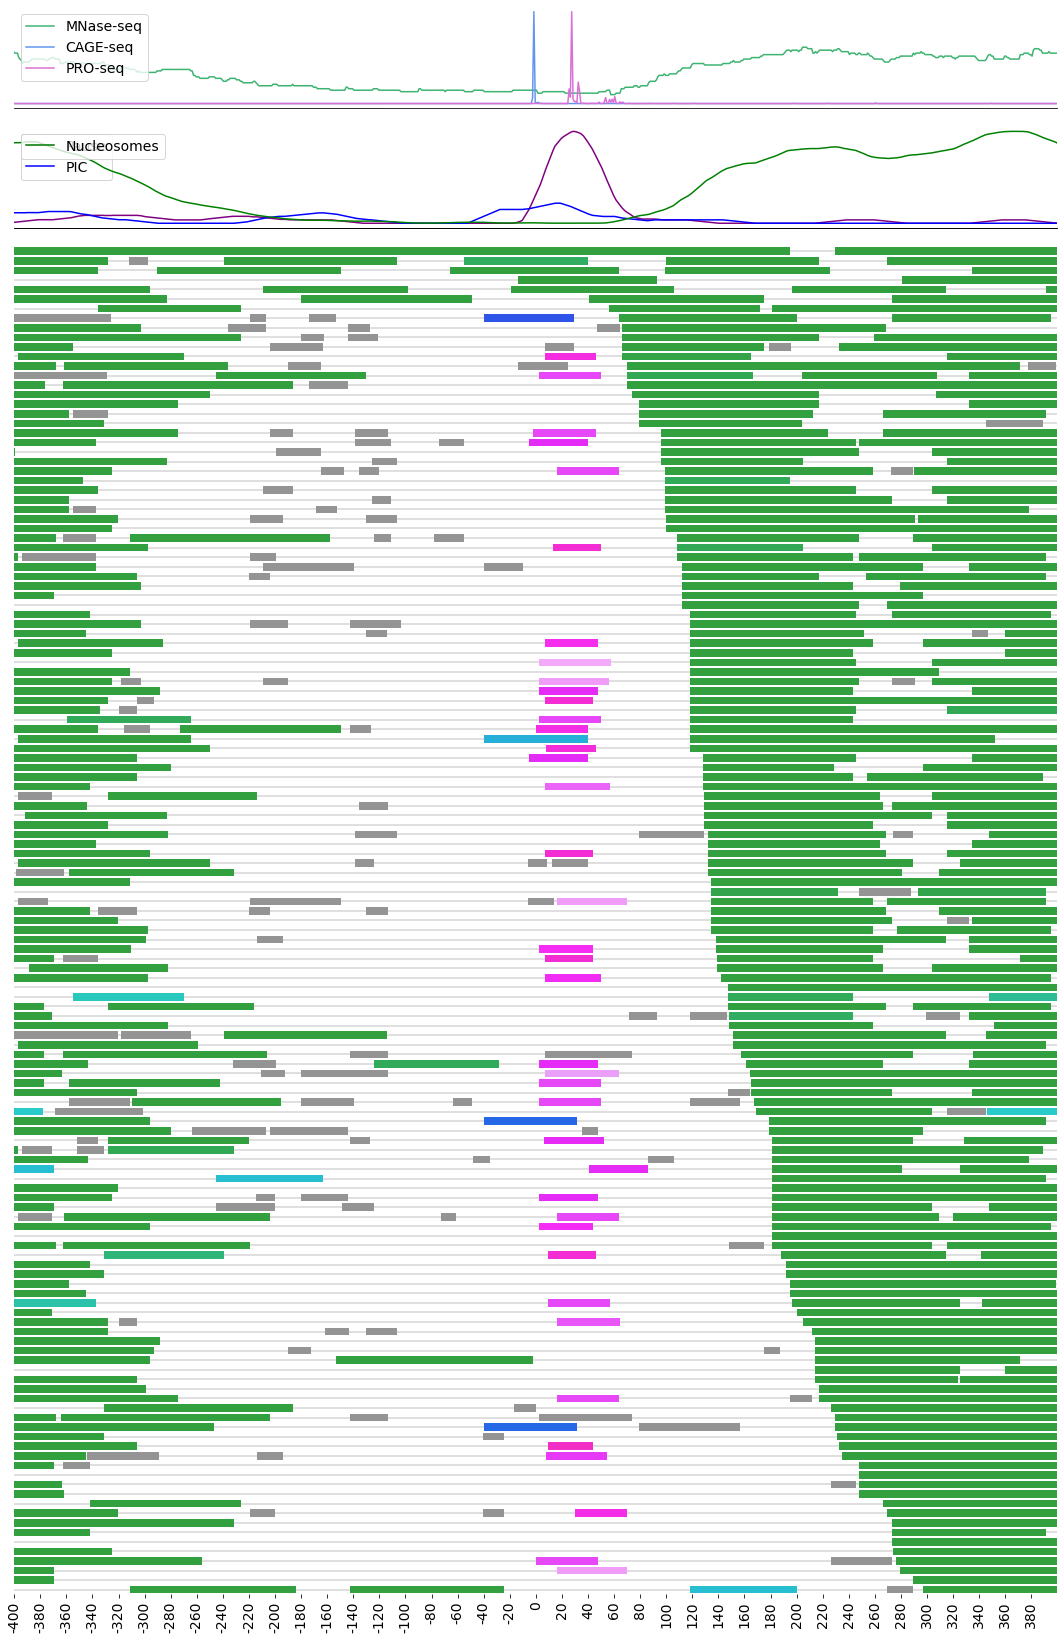

FBgn0024291


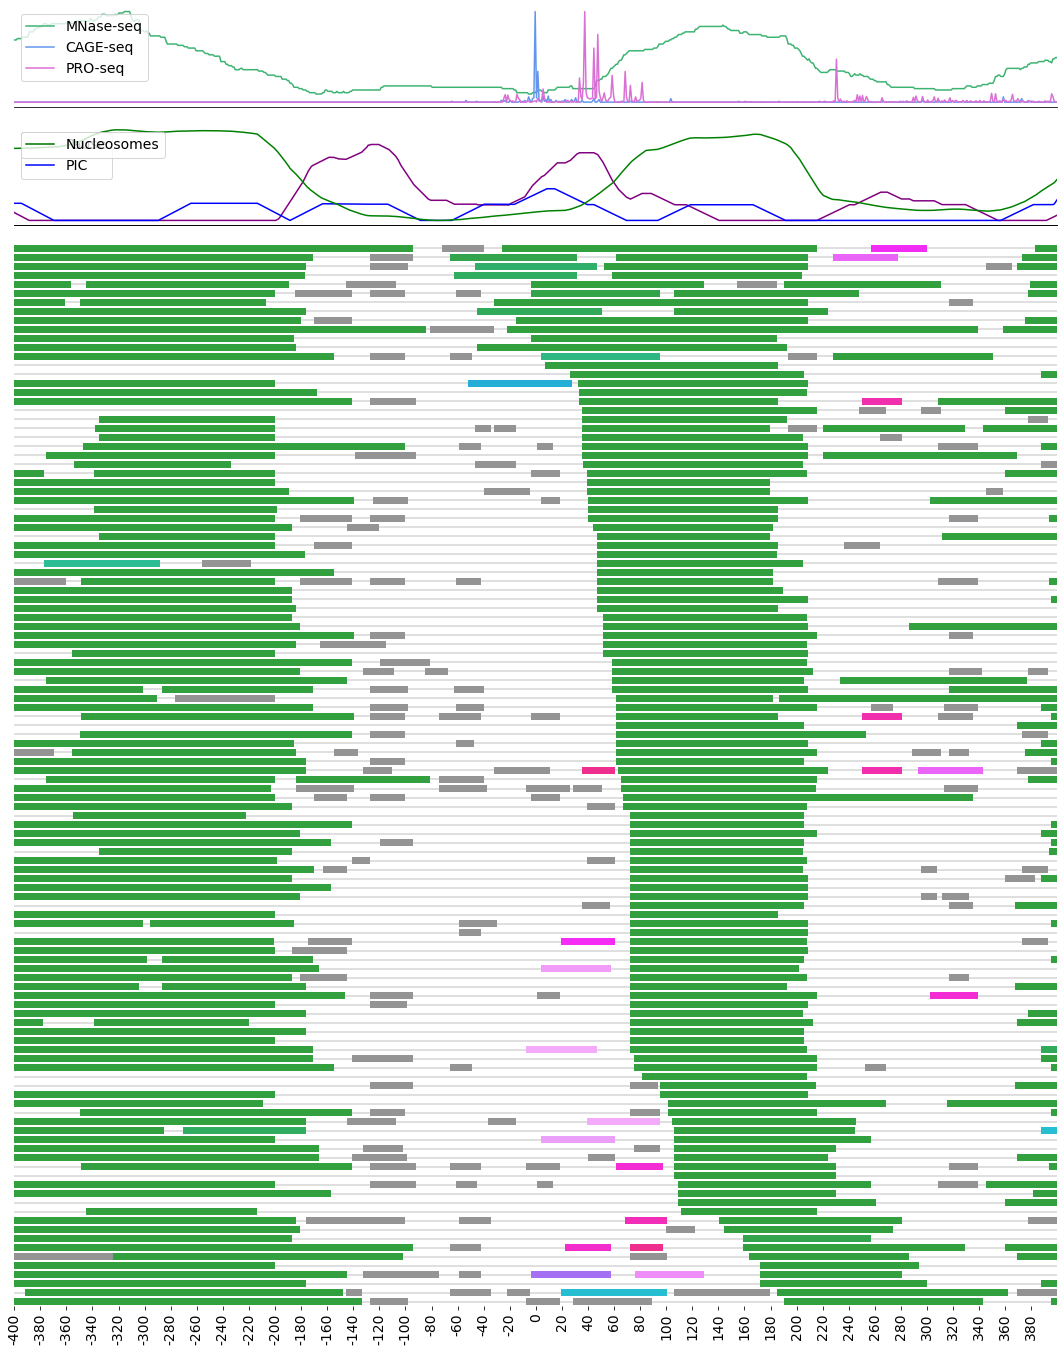

FBgn0003278


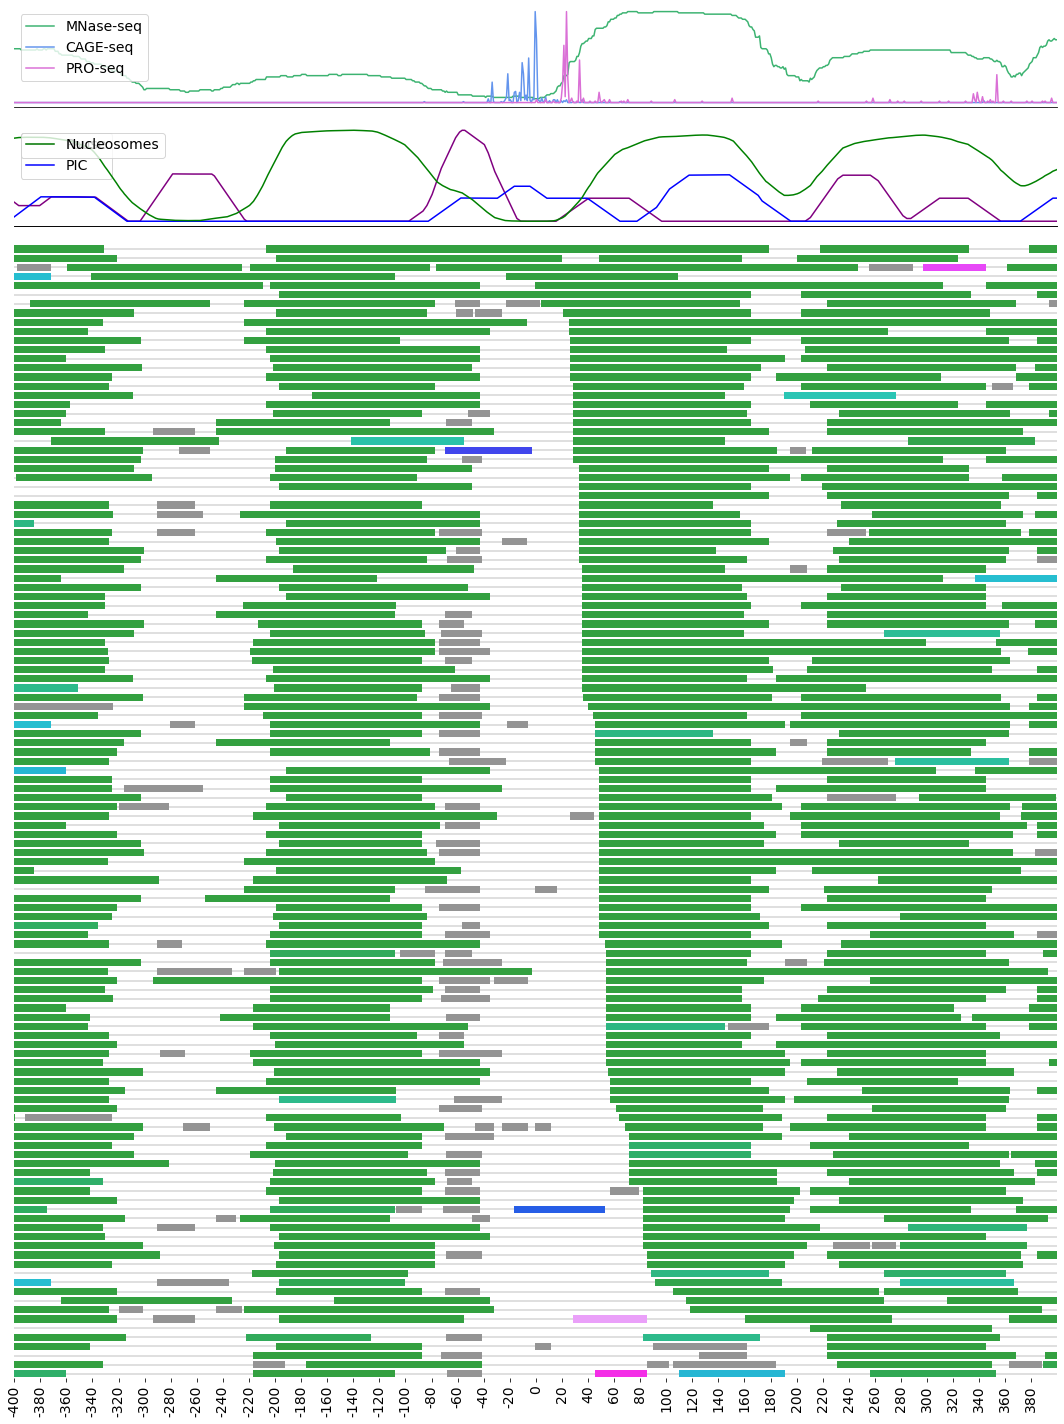

In [12]:
s=-400
e=400
condition='untreated'

smooth=25
for g in ['FBgn0031745', 'FBgn0051955','FBgn0003278','FBgn0001142','FBgn0002543','FBgn0024291','FBgn0003278']:    
    if g in pro_peaks and g in cage_peaks:
        print(g)
        genes_tmp=genes_df.loc[(genes_df['condition']=='untreated')&(genes_df['gid']==g)].reset_index()
        genes_tmp['d']=dist_to_fp(genes_tmp,gtf_df,0,300,90,100000)['d']
        genes_tmp=genes_tmp.dropna(subset='d')
        genes_tmp=genes_tmp.sort_values(by='d')
        d=genes_tmp.drop(['dataset','condition', 'gid','d'], axis=1).fillna(0)[np.arange(s,e).astype(str)]
        rows=d.shape[0]

        d2=d.copy()
        d2=d2.mask(d2>=80,0)
        d2=d2.mask(d2<=10,0)
        id_df=[]
        idc=[]
        k=1
        for index, row in d2.iterrows():
            r_tmp=np.zeros(len(row))
            row=row.to_numpy()
            a=np.where(row!=0)[0]
            b=np.append(a,[0])
            a=np.append([0],a)
            c=b-a
            c=c[:-1]
            f=np.where(c!=1)[0]
            f=a[f+1]
            for h in f:
                r_tmp[h:h+int(row[h])]+=k
                k+=1
            id_df.append(r_tmp)
            idc.append(index)

        id_df=pd.DataFrame(id_df)
        id_df.index=idc
        id_df.columns=d.columns
        a=d.loc[d[pro_peaks[g].astype(str)].isin(np.arange(30,59)).any(axis=1)]  
        b=d.loc[d[cage_peaks[g].astype(str)].isin(np.arange(60,80)).any(axis=1)]  
        hits=np.unique(id_df.loc[a.index,pro_peaks[g].astype(str)].to_numpy()).tolist()+np.unique(id_df.loc[b.index,cage_peaks[g].astype(str)].to_numpy()).tolist()
        id_df=id_df.mask(id_df.isin(hits), 0)


        mnase_fwd = signal_df_mnase.loc[signal_df_mnase['dataset']=='mnase_15']
        mnase_fwd=mnase_fwd.loc[mnase_fwd['pos'].isin(np.arange(s-100,e+100))]
        mnase_fwd=mnase_fwd.loc[:,g]

        PRO_fwd = signal_df.loc[signal_df['dataset']=='PRO_fwd'].loc[signal_df['pos'].isin(np.arange(s-100,e+100))].loc[:,g]
        CAGE_fwd = signal_df.loc[signal_df['dataset']=='CAGE_fwd'].loc[signal_df['pos'].isin(np.arange(s-100,e+100))].loc[:,g] 

        fig, ax=plt.subplots(3,1, figsize=(15,rows//7+3),gridspec_kw={'height_ratios': [1.5,1.5,rows//7]})

        a=meta_line_plot(genes_tmp,  s-smooth-100, e+smooth+100, 90,100000, False)
        b=meta_line_plot(genes_tmp,  s-smooth-100, e+smooth+100, 40, 60, False)
        c=meta_line_plot(genes_tmp,  s-smooth-100, e+smooth+100, 60, 80, False)

        box = np.ones(smooth)/smooth
        a = np.convolve(a, box, mode='same')
        a = a[smooth:len(a)-smooth]
        b = np.convolve(b, box, mode='same')
        b = b[smooth:len(b)-smooth]
        c = np.convolve(c, box, mode='same')
        c = c[smooth:len(c)-smooth]


        ax[1].plot(np.arange(s-100,e+100),b, color='purple', label='Pause')
        ax[1].plot(np.arange(s-100,e+100),c, color='blue', label='PIC')
        ax[1].set_xlim(s,e)

        ax2 = ax[1].twinx() 
        ax2.plot(np.arange(s-100,e+100),a, color='green',label='Nucleosomes')
        ax2.set_xlim(s,e)

        ax[0].plot(np.arange(s-100,e+100),mnase_fwd/max(mnase_fwd), label='MNase-seq', color='mediumseagreen')
        ax[0].plot(np.arange(s-100,e+100),CAGE_fwd/max(CAGE_fwd), label='CAGE-seq', color='cornflowerblue')
        ax[0].plot(np.arange(s-100,e+100),PRO_fwd/max(PRO_fwd), label='PRO-seq', color='orchid')

        ax[0].set_xlim(s,e)
        ax[0].legend(loc='upper left', ncol=1)
        ax[0].set_xticks([])
        ax[0].set_yticks([])
        ax[0].spines['top'].set_visible(False)
        ax[0].spines['right'].set_visible(False)
        ax[0].spines['left'].set_visible(False)

        ax[1].set_xlim(s,e)
        ax[1].legend(loc='upper left', ncol=1)
        ax[1].set_xticks([])
        ax[1].set_yticks([])
        ax[1].spines['top'].set_visible(False)
        ax[1].spines['right'].set_visible(False)
        ax[1].spines['left'].set_visible(False)
        ax2.set_xlim(s,e)
        ax2.legend(loc='upper left', ncol=1)
        ax2.set_xticks([])
        ax2.set_yticks([])
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)
        ax2.spines['left'].set_visible(False)


     #   
        for i in range(d.shape[0]+1):
            ax[2].axhline(i+.5, color='black', lw=.25, zorder=1)
        for i in range(d.shape[0]+1):
            ax[2].axhline(i, color='white', lw=2, zorder=3)
        sns.heatmap(data=id_df,cmap=mask_cp,vmin=0, vmax=1000, yticklabels=False, cbar=False, ax=ax[2], xticklabels=20,rasterized=True, zorder=3)
        sns.heatmap(data=d, cmap=pol_cp,vmin=0, vmax=100, yticklabels=False, cbar=False, ax=ax[2], xticklabels=20,rasterized=True, zorder=2)
        plt.tight_layout()
      #  plt.savefig('Paper Figures Updated/Figure 1/example loci/hsps/'+g+'_'+str(s)+'-'+str(e)+'.pdf')#,transparent=True)
      #  plt.savefig('Paper Figures Updated/Figure 1/example loci/hsps/'+g+'_'+str(s)+'-'+str(e)+'.png')#,transparent=True)
        plt.show()